<a href="https://colab.research.google.com/github/MariamKSharkawy/ML-projects/blob/ML_DL_projects/weather_predict_streamlit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/weatherAUS[1].csv')

In [ ]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


<Axes: >

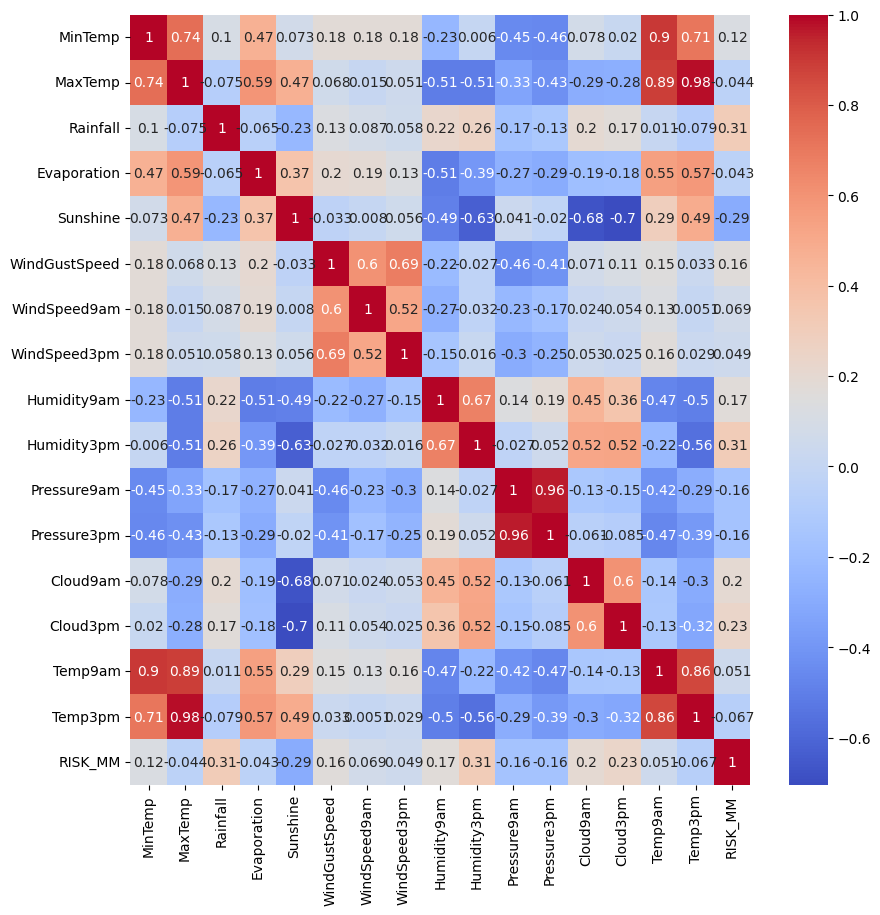

In [ ]:
corr=df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [ ]:
df.dropna(thresh=len(df)-50000,axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   WindGustDir    132863 non-null  object 
 6   WindGustSpeed  132923 non-null  float64
 7   WindDir9am     132180 non-null  object 
 8   WindDir3pm     138415 non-null  object 
 9   WindSpeed9am   140845 non-null  float64
 10  WindSpeed3pm   139563 non-null  float64
 11  Humidity9am    140419 non-null  float64
 12  Humidity3pm    138583 non-null  float64
 13  Pressure9am    128179 non-null  float64
 14  Pressure3pm    128212 non-null  float64
 15  Temp9am        141289 non-null  float64
 16  Temp3pm        139467 non-null  float64
 17  RainToday      140787 non-nul

In [ ]:
df[['MinTemp', 'MaxTemp']] = df[['MinTemp', 'MaxTemp']].fillna(df[['MinTemp', 'MaxTemp']].mode().iloc[0])

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,1406
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013
WindDir3pm,3778
WindSpeed9am,1348


In [ ]:
#drop the columns that have null values and strong correlation with other columns with less nulls
df=df.drop(['MinTemp','Temp3pm','Pressure9am'],axis=1)

In [ ]:
df=df.drop(['WindDir9am','Rainfall'],axis=1)

In [ ]:
df=df.drop(['WindSpeed3pm','Humidity3pm'],axis=1)

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,3778
WindSpeed9am,1348
Humidity9am,1774
Pressure3pm,13981
Temp9am,904


In [ ]:
df[['Temp9am', 'WindSpeed9am']] = df[['Temp9am', 'WindSpeed9am']].fillna(df[['Temp9am', 'WindSpeed9am']].mean().iloc[0])

In [ ]:
df[['Humidity9am']] = df[['Humidity9am']].fillna(df[['Humidity9am']].mean().iloc[0])

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,3778
WindSpeed9am,0
Humidity9am,0
Pressure3pm,13981
Temp9am,0


In [ ]:
df[['WindDir3pm']] = df[['WindDir3pm']].fillna(df[['WindDir3pm']].mode().iloc[0])

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,9330
WindGustSpeed,9270
WindDir3pm,0
WindSpeed9am,0
Humidity9am,0
Pressure3pm,13981
Temp9am,0


In [ ]:
filling=df['WindGustDir'].unique()

In [ ]:
from random import choice
df['WindGustDir']=df['WindGustDir'].fillna(choice(filling))

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,0
WindGustSpeed,9270
WindDir3pm,0
WindSpeed9am,0
Humidity9am,0
Pressure3pm,13981
Temp9am,0


In [ ]:
rain_fill=df['RainToday'].unique()
df['RainToday']=df['RainToday'].fillna(choice(filling))
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,0
WindGustSpeed,9270
WindDir3pm,0
WindSpeed9am,0
Humidity9am,0
Pressure3pm,13981
Temp9am,0


In [ ]:
df[['WindGustSpeed','Pressure3pm']] = df[['WindGustSpeed','Pressure3pm']].fillna(df[['WindGustSpeed','Pressure3pm']].mean().iloc[0])

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MaxTemp,0
WindGustDir,0
WindGustSpeed,0
WindDir3pm,0
WindSpeed9am,0
Humidity9am,0
Pressure3pm,0
Temp9am,0


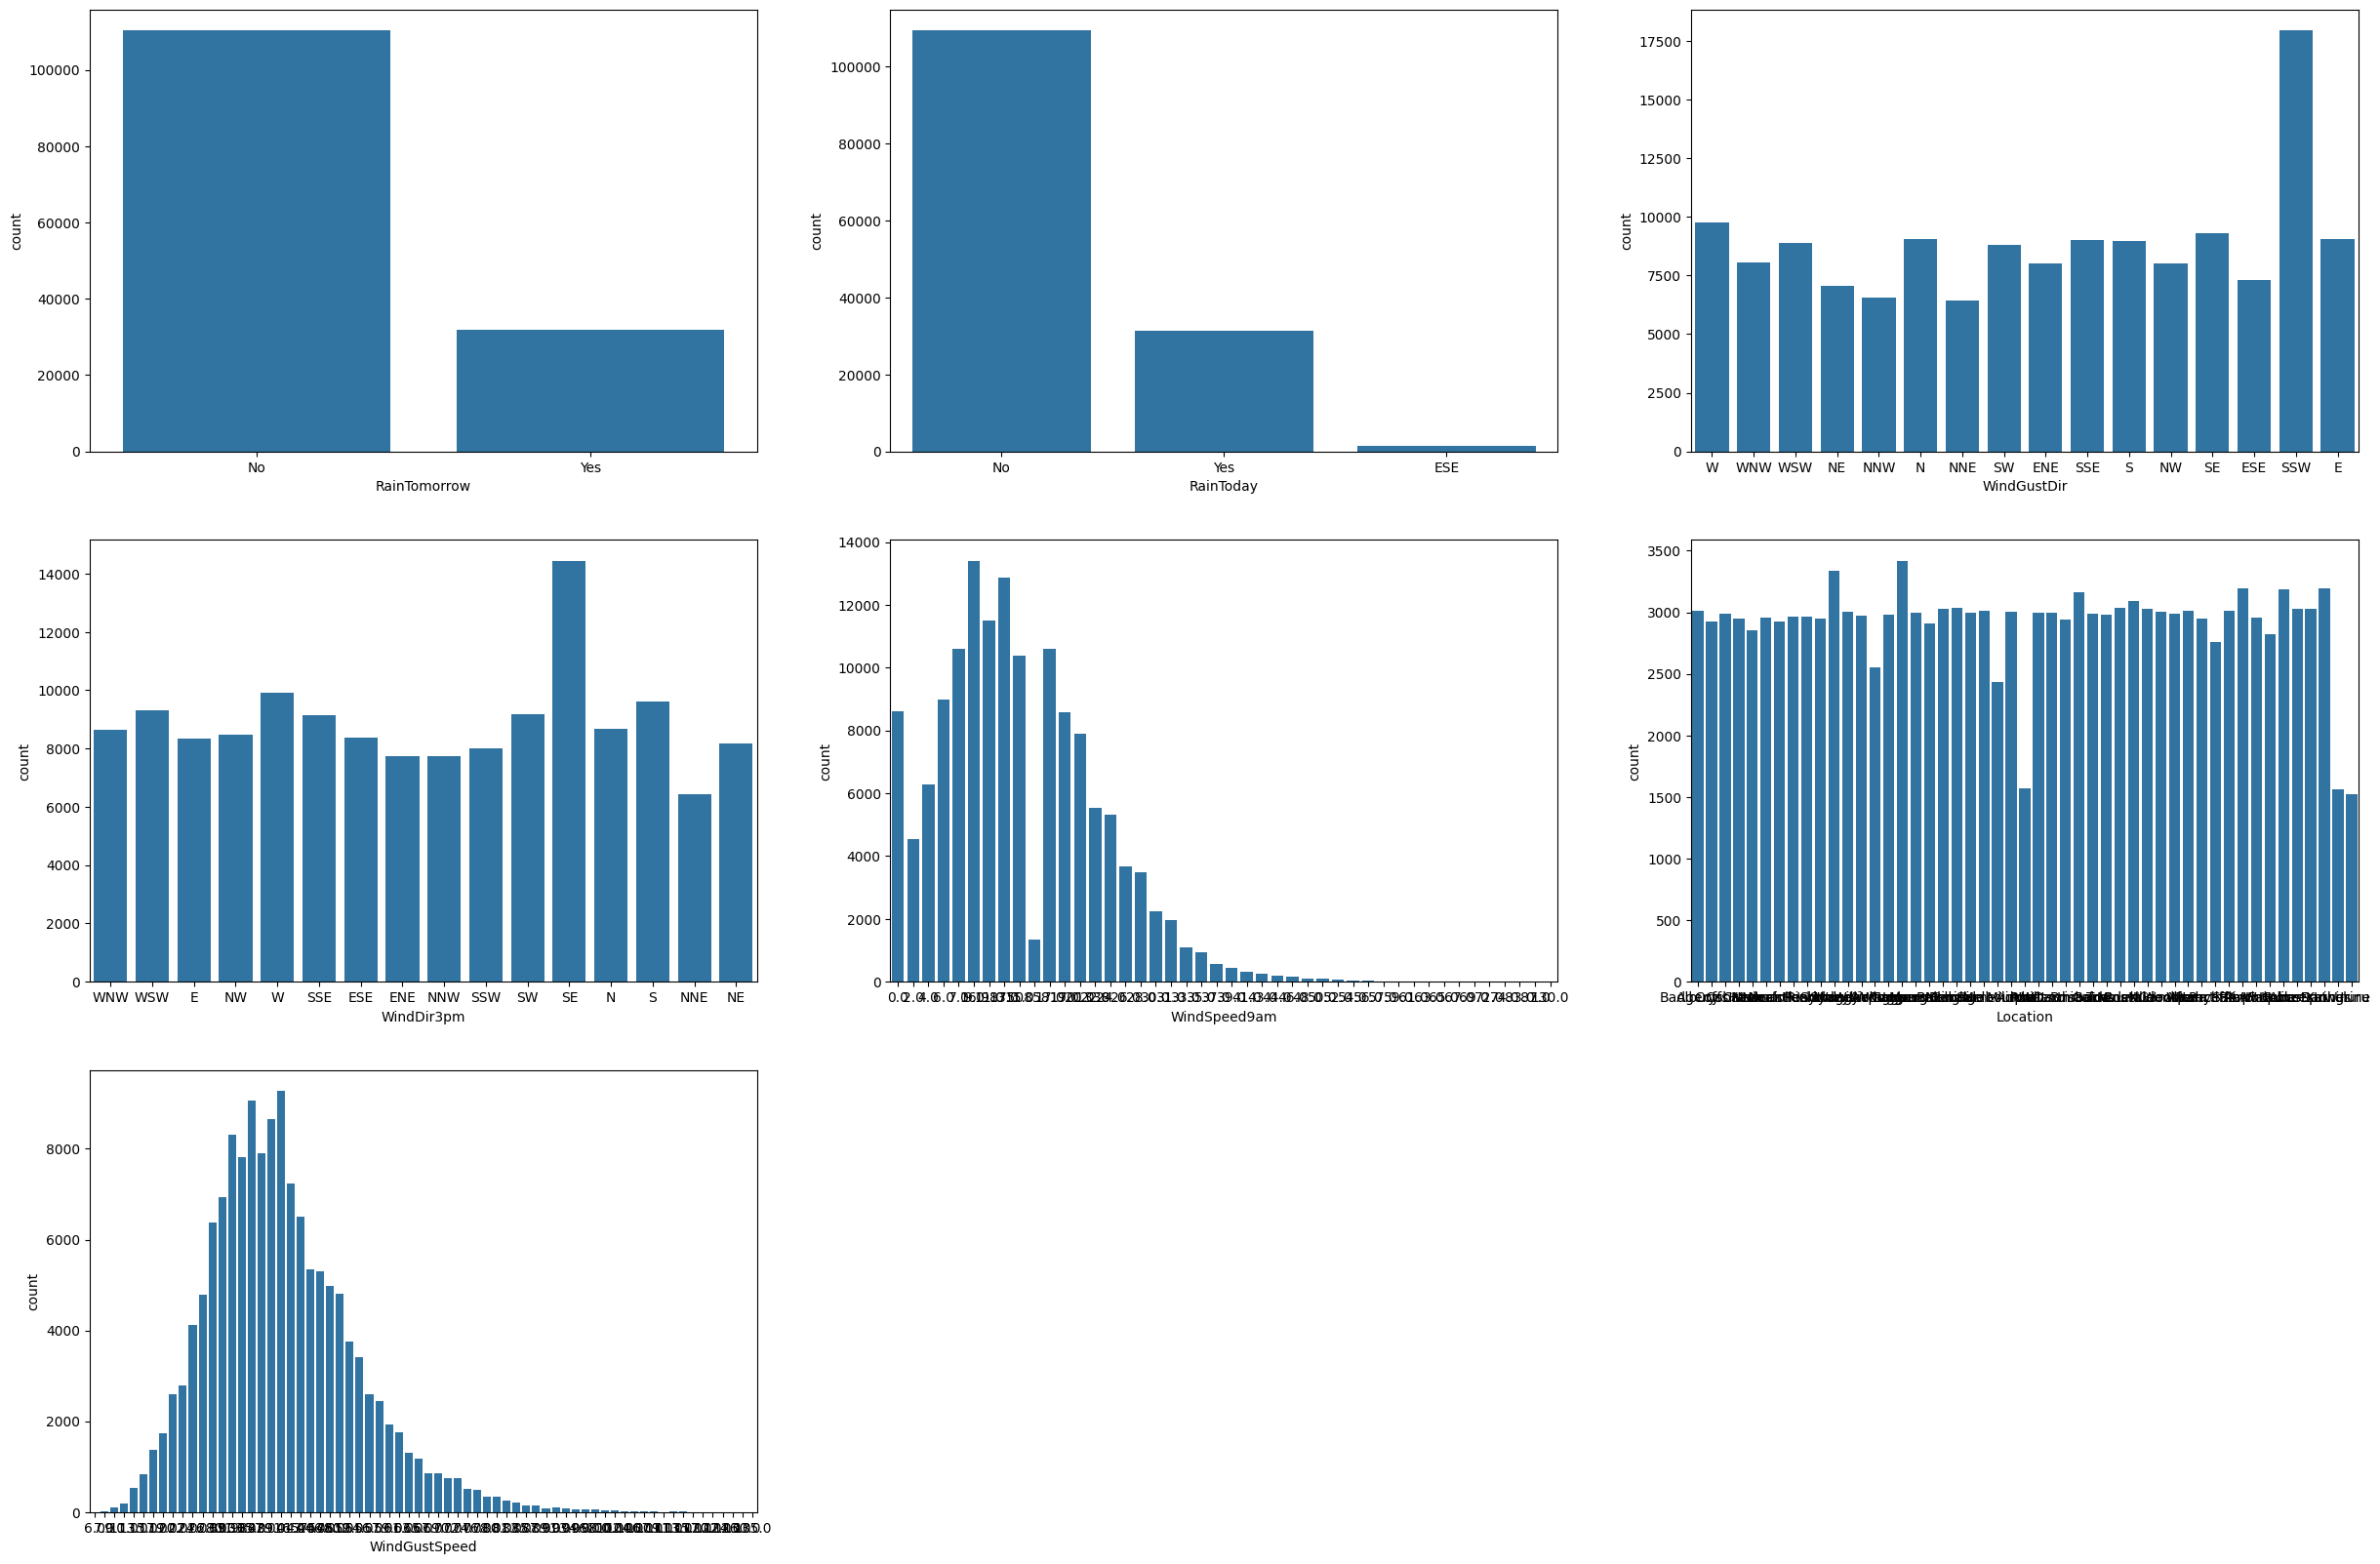

In [ ]:
cols = list(df.nunique().sort_values().index[:7])
cols
plt.figure(figsize=(30,20))
for n , col in enumerate(cols) :
    plt.subplot(3,3,n+1)
    sns.countplot(data=df,x=col)

<Axes: >

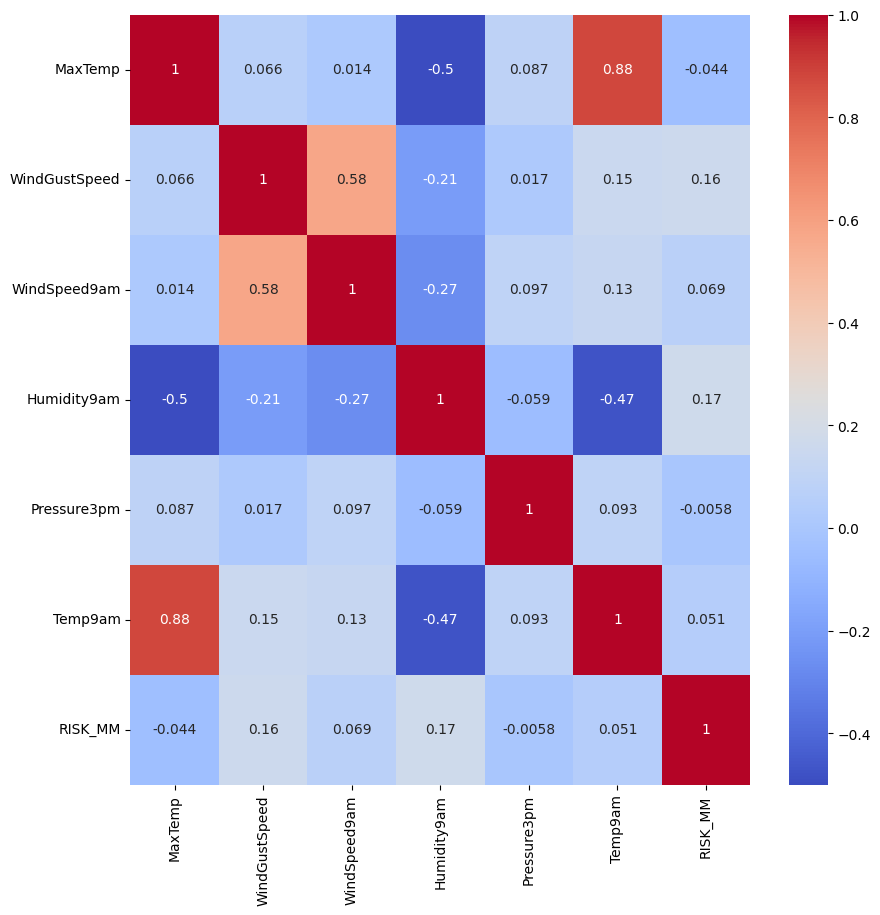

In [ ]:
corr=df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MaxTemp        142193 non-null  float64
 3   WindGustDir    142193 non-null  object 
 4   WindGustSpeed  142193 non-null  float64
 5   WindDir3pm     142193 non-null  object 
 6   WindSpeed9am   142193 non-null  float64
 7   Humidity9am    142193 non-null  float64
 8   Pressure3pm    142193 non-null  float64
 9   Temp9am        142193 non-null  float64
 10  RainToday      142193 non-null  object 
 11  RISK_MM        142193 non-null  float64
 12  RainTomorrow   142193 non-null  object 
dtypes: float64(7), object(6)
memory usage: 14.1+ MB


In [ ]:
import os
import pickle
from sklearn.preprocessing import LabelEncoder

# Create a directory to store the encoders if it doesn't already exist
os.makedirs("saved_models", exist_ok=True)

# Create an empty dictionary to store encoders
encoders = {}

# List of categorical columns
categorical_columns = ['Location', 'WindGustDir', 'WindDir3pm', 'RainToday']

# Fit and transform each categorical column separately
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Transform the column
    encoders[col] = le  # Store the encoder in the dictionary

    # Save each encoder in a separate file
    with open(f"saved_models/{col}_label_encoder.pkl", "wb") as f:
        pickle.dump(le, f)

# Now, each LabelEncoder is saved in a separate file with the column name as part of the file name.



In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[ns]
 1   Location       142193 non-null  int64         
 2   MaxTemp        142193 non-null  float64       
 3   WindGustDir    142193 non-null  int64         
 4   WindGustSpeed  142193 non-null  float64       
 5   WindDir3pm     142193 non-null  int64         
 6   WindSpeed9am   142193 non-null  float64       
 7   Humidity9am    142193 non-null  float64       
 8   Pressure3pm    142193 non-null  float64       
 9   Temp9am        142193 non-null  float64       
 10  RainToday      142193 non-null  int64         
 11  RISK_MM        142193 non-null  float64       
 12  RainTomorrow   142193 non-null  object        
 13  Year           142193 non-null  int32         
 14  Month          142193 non-null  int32         
 15  

In [ ]:
df.drop('Date',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  int64  
 1   MaxTemp        142193 non-null  float64
 2   WindGustDir    142193 non-null  int64  
 3   WindGustSpeed  142193 non-null  float64
 4   WindDir3pm     142193 non-null  int64  
 5   WindSpeed9am   142193 non-null  float64
 6   Humidity9am    142193 non-null  float64
 7   Pressure3pm    142193 non-null  float64
 8   Temp9am        142193 non-null  float64
 9   RainToday      142193 non-null  int64  
 10  RISK_MM        142193 non-null  float64
 11  RainTomorrow   142193 non-null  object 
 12  Year           142193 non-null  int32  
 13  Month          142193 non-null  int32  
 14  Day            142193 non-null  int32  
dtypes: float64(7), int32(3), int64(4), object(1)
memory usage: 14.6+ MB


In [ ]:
x=df.drop('RainTomorrow',axis=1)
y=df['RainTomorrow']

In [ ]:
y = le.fit_transform(y)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
DT = DecisionTreeRegressor(criterion='squared_error',max_depth=10)
DT.fit(X_train,y_train)
DT.score(X_train,y_train)

1.0

In [ ]:
DT.score(X_test,y_test)

1.0

In [ ]:
y_pred = DT.predict(X_test)

In [ ]:
from  sklearn.metrics import mean_absolute_error , mean_squared_error,root_mean_squared_error,r2_score
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",root_mean_squared_error(y_test,y_pred))
print("R2 : ",r2_score(y_test,y_pred))

MAE :  0.0
MSE :  0.0
RMSE :  0.0
R2 :  1.0


In [ ]:
import pickle
import os

# Make sure your variables already exist in the workspace
# Assumes you have: le, sc, DT, knn, model, X_train, X_test, y_train, y_test

# Save StandardScaler
with open("saved_models/scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

# Save Decision Tree model
with open("saved_models/decision_tree_model.pkl", "wb") as f:
    pickle.dump(DT, f)



print("✅ All models and preprocessing files saved in the 'saved_models' folder.")


✅ All models and preprocessing files saved in the 'saved_models' folder.
